# Segmentierung von Telekom-Abonnenten mit k-Means-Clustering


## Zusammenfassung

Ein Telekommunikationsanbieter möchte seine Postpaid-Abonnentenbasis in Verhaltenssegmente gruppieren, um Kundenbindungsangebote gezielt einzusetzen und Datentarife passend zuzuschneiden. Dieses Notebook erzeugt einen synthetischen Datensatz zur Abonnentennutzung und führt anschließend eine vollständige k-Means-Segmentierungspipeline in Base SAS aus: Die Nutzungstreiber werden mit **PROC STDIZE** standardisiert, die Clusteranzahl wird durch Vergleich der Pseudo-F-Statistik über Kandidaten-k mit **PROC FASTCLUS** bestimmt, ein FREQ-gewichtetes finales Modell bewertet jeden Abonnenten, und die gelernten Zentren werden exportiert, damit die Momentaufnahme des nächsten Monats ohne erneutes Clustering bewertet werden kann. Das Ergebnis ist eine wiederverwendbare Segmentierung, die rohe Nutzungstelemetrie auf ein Kundenbindungs-Playbook abbildet.

## Datenquellen

**Synthetischer Datensatz: `WORK.SUBSCRIBERS`** (100 Postpaid-Mobilfunkkunden, inline erzeugt mit `call streaminit(20260531)`)

| Variable | Typ | Rolle | Beschreibung |
|----------|------|------|-------------|
| `cust_id` | Zeichen | ID | Kundenkennung (z. B. `SUB000123`) |
| `tenure_months` | Numerisch | Intervall-Eingabe | Monate, die der Anschluss aktiv ist (1-72) |
| `data_gb` | Numerisch | Intervall-Eingabe | Durchschnittlich genutztes mobiles Datenvolumen pro Monat, in GB |
| `voice_min` | Numerisch | Intervall-Eingabe | Durchschnittliche Sprachminuten pro Monat |
| `intl_min` | Numerisch | Intervall-Eingabe | Durchschnittliche Auslandsminuten pro Monat |
| `support_calls` | Numerisch | Intervall-Eingabe | Support-Kontakte in den letzten 90 Tagen |
| `monthly_charge` | Numerisch | Intervall-Eingabe | Aktuelle monatliche Rechnung, in Dollar |
| `plan_tier` | Zeichen | Profilierung | Tarifstufe: `Basis`, `Plus` oder `Unbegrenzt` |
| `n_lines` | Numerisch | FREQ-Gewicht | Anschlüsse auf dem Konto |

Drei latente Verhaltensprofile sind im Generator eingebettet - *sparsam/preisbewusst*, *datenintensiv/Streaming* und *betreuungsintensiv/abwanderungsgefährdet* - sodass beim Clustering echte Struktur zu entdecken ist. Die Intervall-Treiber fließen in das k-Means-Modell ein; `plan_tier` wird für die nachträgliche Profilierung zurückgehalten, und `n_lines` gewichtet jedes Konto nach seiner Anzahl an Anschlüssen. Es werden keine externen Dateien oder Netzwerkzugriffe verwendet.

## Verhaltensbasierte Segmentierung in fünf Schritten

Mobilfunkanbieter betreuen Millionen von Postpaid-Anschlüssen, und eine Einheitsstrategie zur Kundenbindung verschwendet Marge bei Kunden, die ohnehin bleiben würden, während die abwanderungsgefährdeten übersehen werden. **Verhaltensbasierte Segmentierung** verwandelt rohe Nutzungstelemetrie in eine Handvoll umsetzbarer Kundentypen: *sparsame/preisbewusste* Nutzer, *datenintensive Streamer*, die gute Upsell-Ziele sind, und *betreuungsintensive/abwanderungsgefährdete* Konten, die proaktive Betreuung brauchen.

Dieses Notebook erstellt die Segmentierung mit `PROC FASTCLUS`, SAS' k-Means-(disjunktes Cluster)-Verfahren. Wir werden:

1. Einen synthetischen, aber realistischen Datensatz zur Abonnentennutzung erzeugen.
2. Die Nutzungstreiber mit **PROC STDIZE** auf eine gemeinsame Skala bringen.
3. **Die Clusteranzahl wählen**, indem die Pseudo-F-Statistik über Kandidaten-k verglichen wird.
4. Ein FREQ-gewichtetes finales Modell anpassen, das jeden Abonnenten **bewertet** und die Segmente profiliert.
5. **Die gelernten Zentren exportieren**, damit das Modell auf die Momentaufnahme des nächsten Monats erneut angewendet werden kann.

## Schritt 1 - Eine synthetische Abonnentenbasis erzeugen

Wir simulieren 100 Postpaid-Abonnenten. Jeder wird aus einem von drei latenten Profilen mit unterschiedlichen Nutzungssignaturen gezogen, sodass eine echte Clusterstruktur zu entdecken ist. Wir fixieren den Zufallsstrom mit `call streaminit` zur Reproduzierbarkeit und begrenzen die simulierten Werte mit `max`/`min`/`round` auf plausible Bereiche.

Die nominale `plan_tier` korreliert mit dem latenten Profil (Streamer neigen zu *Unbegrenzt*; preisbewusste Nutzer zu *Basis*), und `n_lines` dient später als FREQ-Gewicht, damit Mehrleitungs-Familienkonten proportional zählen.

In [1]:
DATEN subscribers;
    AUFRUFEN streaminit(20260531);
    LÄNGE cust_id $9 plan_tier $12;
    AUSFÜHRUNG i = 1 BIS 100;
        cust_id = cats('SUB', PUT(i, z6.));

        /* Drei latente Verhaltensprofile, unterschiedlich häufig */
        u = rand('uniform');
        WENN u < 0.45 DANN profile = 1;        /* sparsam / preisbewusst              */
        SONST WENN u < 0.80 DANN profile = 2;   /* datenintensiver Streamer            */
        SONST profile = 3;                    /* betreuungsintensiv / abwanderungsgefährdet */

        WENN profile = 1 DANN AUSFÜHRUNG;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 30, 14))));
            data_gb        = MAX(0.2, rand('normal', 3,  1.5));
            voice_min      = MAX(0,   rand('normal', 180, 60));
            intl_min       = MAX(0,   rand('exponential') * 8);
            support_calls  = rand('poisson', 0.6);
            monthly_charge = MAX(15, rand('normal', 45, 8));
        ENDE;
        SONST WENN profile = 2 DANN AUSFÜHRUNG;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 40, 16))));
            data_gb        = MAX(0.2, rand('normal', 22, 6));
            voice_min      = MAX(0,   rand('normal', 320, 90));
            intl_min       = MAX(0,   rand('exponential') * 25);
            support_calls  = rand('poisson', 1.2);
            monthly_charge = MAX(15, rand('normal', 85, 12));
        ENDE;
        SONST AUSFÜHRUNG;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 12, 8))));
            data_gb        = MAX(0.2, rand('normal', 9,  4));
            voice_min      = MAX(0,   rand('normal', 240, 80));
            intl_min       = MAX(0,   rand('exponential') * 15);
            support_calls  = rand('poisson', 5.5);
            monthly_charge = MAX(15, rand('normal', 70, 18));
        ENDE;

        /* Tarifstufe korreliert mit Profil */
        p = rand('uniform');
        WENN profile = 1 DANN
            plan_tier = ifc(p < 0.70, 'Basis', ifc(p < 0.95, 'Plus', 'Unbegrenzt'));
        SONST WENN profile = 2 DANN
            plan_tier = ifc(p < 0.65, 'Unbegrenzt', ifc(p < 0.90, 'Plus', 'Basis'));
        SONST
            plan_tier = ifc(p < 0.45, 'Plus', ifc(p < 0.80, 'Unbegrenzt', 'Basis'));

        /* Anschlüsse auf dem Konto: die meisten sind Einzelanschlüsse */
        n_lines = 1 + rand('binomial', 0.35, 3);

        /* Geld-/Nutzungswerte auf realistische Genauigkeit runden */
        data_gb        = round(data_gb, 0.1);
        voice_min      = round(voice_min);
        intl_min       = round(intl_min);
        monthly_charge = round(monthly_charge, 0.01);

        AUSGABE;
    ENDE;
    ENTFERNEN i u p profile;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=subscribers(obs=10) noobs BEZEICHNUNG;
    BEZEICHNUNG cust_id='Kundennummer' tenure_months='Vertragsdauer (Monate)'
          data_gb='Datenvolumen (GB)' voice_min='Sprachminuten'
          intl_min='Auslandsminuten' support_calls='Support-Anrufe'
          monthly_charge='Monatliche Rechnung ($)' plan_tier='Tarifstufe'
          n_lines='Anzahl Anschlüsse';
    TITEL 'Stichprobe synthetischer Abonnenten-Nutzungsdaten';
AUSFÜHREN;

                                   Stichprobe synthetischer Abonnenten-Nutzungsdaten                                    

Kundennummer  Tarifstufe  Vertragsdauer (Monate)  Datenvolumen (GB)  Sprachminuten  Auslandsminuten  Support-Anrufe  Monatliche Rechnung ($)   Anzahl Anschlüsse
SUB000001     Basis                           15                9.7            114                5              11                    57.07                   2
SUB000002     Basis                           39                0.6            214                2               1                    35.88                   3
SUB000003     Unbegrenzt                      45               23.9            325                6               1                   103.94                   2
SUB000004     Basis                           41                1.9            202                1               0                    61.69                   3
SUB000005     Basis                           34                2.8      


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC PRINT data=subscribers

NOTE: PROC PRINT completed: 10 observations printed, 9 variables


## Schritt 2 - Die Treiber auf eine gemeinsame Skala bringen

k-Means verwendet die euklidische Distanz, sodass eine großskalige Variable wie Sprachminuten eine kleinskalige wie Support-Anrufe dominieren würde, wenn wir mit den Rohwerten clustern. Die Standardlösung ist, jeden Intervall-Treiber zunächst auf Mittelwert 0 und Standardabweichung 1 zu standardisieren. **PROC STDIZE** mit `METHOD=STD` tut genau das und schreibt die z-standardisierte Kopie nach `WORK.SUBS_STD`. Wir führen `cust_id`, `plan_tier` und `n_lines` unverändert mit, damit sie später für Gewichtung und Profilierung zur Verfügung stehen.

In [2]:
PROZEDUR stdize DATEN=subscribers out=subs_std METHOD=std;
    VAR tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    BEZEICHNUNG tenure_months='Vertragsdauer (Monate)' data_gb='Datenvolumen (GB)'
          voice_min='Sprachminuten' intl_min='Auslandsminuten'
          support_calls='Support-Anrufe' monthly_charge='Monatliche Rechnung ($)';
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=subs_std mean std maxdec=3;
    VAR tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    BEZEICHNUNG tenure_months='Vertragsdauer (Monate)' data_gb='Datenvolumen (GB)'
          voice_min='Sprachminuten' intl_min='Auslandsminuten'
          support_calls='Support-Anrufe' monthly_charge='Monatliche Rechnung ($)';
    TITEL 'Standardisierte Treiber: Mittelwert ~ 0, Std ~ 1';
AUSFÜHREN;

                                   Stichprobe synthetischer Abonnenten-Nutzungsdaten                                    

                                    Standardisierte Treiber: Mittelwert ~ 0, Std ~ 1                                    

                                                  The MEANS Procedure

 Variable        Label                             Mean     Std Dev
 ------------------------------------------------------------------
 tenure_months   Vertragsdauer (Monate)           0.000       1.000
 data_gb         Datenvolumen (GB)               -0.000       1.000
 voice_min       Sprachminuten                   -0.000       1.000
 intl_min        Auslandsminuten                  0.000       1.000
 support_calls   Support-Anrufe                  -0.000       1.000
 monthly_charge  Monatliche Rechnung ($)          0.000       1.000
 ------------------------------------------------------------------




NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Schritt 3 - Wie viele Segmente? Vergleich der Pseudo-F-Statistik über Kandidaten-k

Statt die Clusteranzahl zu raten, passen wir FASTCLUS für jedes Kandidaten-k an und lesen die berichteten Modellgüte-Statistiken ab. Sowohl die **Pseudo-F-Statistik** (ein Verhältnis von Zwischen- zu Innerhalb-Cluster-Varianz) als auch das **Gesamt-R-Quadrat** belohnen Trennschärfe; ein gutes k liegt dort, wo die Pseudo-F hoch ist und ein weiterer Cluster nur noch abnehmenden Nutzen bringt. Eine kurze Makroschleife führt k = 2, 3, 4 mit `MAXITER=50` und `CONVERGE=0` aus (bis zur Stabilität iterieren). Vergleichen Sie die Zeilen `Pseudo F Statistic` und `Overall R-Squared` in den drei folgenden Listings: Die eingebettete Struktur hat drei latente Profile, und k = 3 liefert die stärkste, ausgewogenste Lösung.

In [3]:
%macro pick_k;
    %AUSFÜHRUNG k = 2 %BIS 4;
        PROZEDUR FASTCLUS DATEN=subs_std maxclusters=&k MAXITER=50 CONVERGE=0;
            VAR tenure_months data_gb voice_min intl_min support_calls monthly_charge;
            BEZEICHNUNG tenure_months='Vertragsdauer (Monate)' data_gb='Datenvolumen (GB)'
                  voice_min='Sprachminuten' intl_min='Auslandsminuten'
                  support_calls='Support-Anrufe' monthly_charge='Monatliche Rechnung ($)';
            TITEL "Kandidaten-Clusteranzahl: k = &k";
        AUSFÜHREN;
    %ENDE;
%mend pick_k;
%pick_k;

                                    Standardisierte Treiber: Mittelwert ~ 0, Std ~ 1                                    


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  41         0.9639             4.8215              2         2.8826
2                  59         0.6989             4.7667              1         2.8826

                                                Statistics for Variables              


NOTE: PROC FASTCLUS data=subs_std maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 2 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 4 clusters using k-means


## Schritt 4 - Die finale Segmentierung anpassen und jeden Abonnenten bewerten

Mit der Wahl k = 3 passen wir das Produktionsmodell an. Dieser Lauf ist voll idiomatisch für eine operative Segmentierung:

- Die `FREQ`-Anweisung gewichtet jedes Konto nach `n_lines`, sodass ein Vierleitungs-Familienkonto bei der Berechnung der Zentren viermal so stark beiträgt wie ein Einzelanschluss.
- `OUT=SCORED` schreibt jeden Abonnenten mit seinem zugewiesenen `CLUSTER` und seiner `DISTANCE` zum Zentrum dieses Clusters; die `ID`-Anweisung führt `cust_id` in diese bewertete Tabelle mit.
- `MEAN=SEG_MEANS` erfasst die Zentren je Cluster (auf standardisierter Skala).
- `OUTSEED=SEG_SEEDS` speichert die finalen Zentren im Seed-Format, das FASTCLUS zurücklesen kann - dies ist das exportierte Modell, das wir in Schritt 6 erneut anwenden.

Die Modellgüte-Statistiken wurden bereits im Schritt-3-Durchlauf ermittelt, daher fügen wir hier die Option `SHORT` hinzu, damit sich das Listing auf die Clustergrößen und Zentren konzentriert, die die Bewertungsausgabe treiben.

In [4]:
PROZEDUR FASTCLUS DATEN=subs_std maxclusters=3 MAXITER=50 CONVERGE=0 short
        out=scored mean=seg_means outseed=seg_seeds;
    VAR tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    HÄUFIGKEITEN n_lines;
    id cust_id;
    BEZEICHNUNG tenure_months='Vertragsdauer (Monate)' data_gb='Datenvolumen (GB)'
          voice_min='Sprachminuten' intl_min='Auslandsminuten'
          support_calls='Support-Anrufe' monthly_charge='Monatliche Rechnung ($)'
          cust_id='Kundennummer' CLUSTER='Cluster-Nr' distance='Abstand';
    TITEL 'Finale Segmentierung: k = 3, FREQ-gewichtet nach Anzahl Anschlüsse';
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=seg_means noobs BEZEICHNUNG;
    BEZEICHNUNG CLUSTER='Cluster-Nr' tenure_months='Vertragsdauer (Monate)'
          data_gb='Datenvolumen (GB)' voice_min='Sprachminuten'
          intl_min='Auslandsminuten' support_calls='Support-Anrufe'
          monthly_charge='Monatliche Rechnung ($)' _freq_='Anzahl';
    TITEL 'Segment-Zentren (standardisierte Skala)';
AUSFÜHREN;

                                    Standardisierte Treiber: Mittelwert ~ 0, Std ~ 1                                    


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8651              2         3.1977
2                  31         0.8130             3.4539              3         3.0115
3                  18         0.8596             4.1352              2         3.0115




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC PRINT data=seg_means

NOTE: PROC PRINT completed: 3 observations printed, 8 variables


## Schritt 5 - Die Segmente in Geschäftseinheiten profilieren

Die bewertete Tabelle führt die `CLUSTER`-Zuordnung jedes Abonnenten mit, aber auf standardisierter Skala sind die Zentren schwer zu lesen. Um Clusternummern in Geschäfts-Personas zu verwandeln, verknüpfen wir die Zuordnung mit der ursprünglichen `subscribers`-Tabelle zurück und profilieren in realen Einheiten - Gigabyte, Minuten und Dollar. PROC MEANS fasst die Intervall-Treiber je Segment zusammen, und PROC FREQ kreuztabelliert die zurückgehaltene `plan_tier` gegen das Segment, um den Tarif-Mix jeder Persona zu zeigen.

                       Segmentprofile: Durchschnittliche Nutzung nach Cluster (Originaleinheiten)                       

                                                  The MEANS Procedure

                               Analysis Variable : tenure_months Vertragsdauer (Monate)

                                           N
                           Cluster-Nr    Obs      Mean      Std Dev      Minimum      Maximum
                           ------------------------------------------------------------------
                           1              51      33.2         14.7          1.0         61.0
                           2              31      40.5         14.0         17.0         67.0
                           3              18      12.7          7.1          1.0         30.0
                           ------------------------------------------------------------------

                                     Analysis Variable : data_gb Datenvolumen (GB)

                        


NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote scored_keys (100 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_plan_tier.spec.json
NOTE: PROC FREQ statement used.


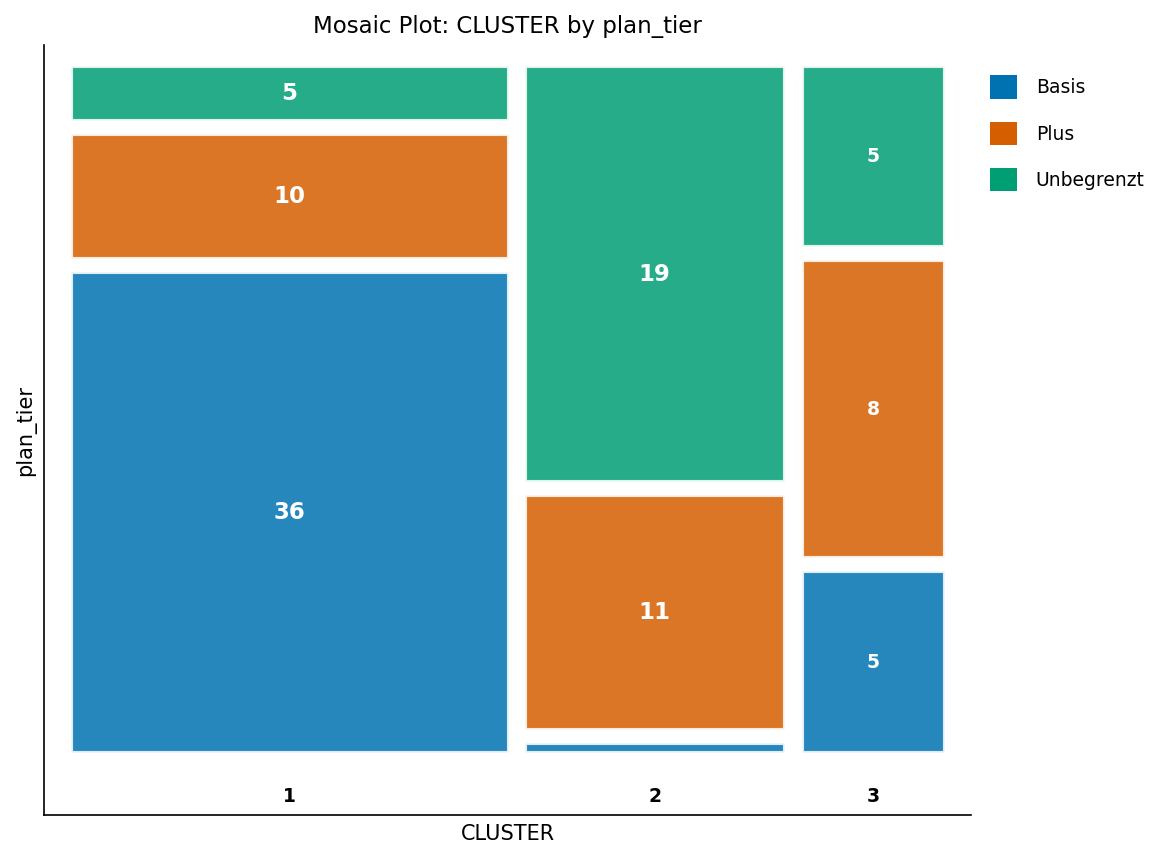

In [5]:
PROZEDUR SORTIEREN DATEN=scored out=scored_keys(BEHALTEN=cust_id CLUSTER);
    NACH cust_id;
AUSFÜHREN;

PROZEDUR SORTIEREN DATEN=subscribers out=subs_sorted;
    NACH cust_id;
AUSFÜHREN;

DATEN profile;
    ZUSAMMENFÜHREN subs_sorted(in=a) scored_keys(in=b);
    NACH cust_id;
    WENN a UND b;
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=profile mean std MIN MAX maxdec=1;
    KLASSE CLUSTER;
    VAR tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    BEZEICHNUNG CLUSTER='Cluster-Nr' tenure_months='Vertragsdauer (Monate)'
          data_gb='Datenvolumen (GB)' voice_min='Sprachminuten'
          intl_min='Auslandsminuten' support_calls='Support-Anrufe'
          monthly_charge='Monatliche Rechnung ($)';
    TITEL 'Segmentprofile: Durchschnittliche Nutzung nach Cluster (Originaleinheiten)';
AUSFÜHREN;

PROZEDUR HÄUFIGKEITEN DATEN=profile;
    TABLES CLUSTER * plan_tier / nocol nopercent;
    BEZEICHNUNG CLUSTER='Cluster-Nr' plan_tier='Tarifstufe';
    TITEL 'Tarifstufen-Mix innerhalb jedes Segments';
AUSFÜHREN;

## Schritt 6 - Das Modell auf die Momentaufnahme des nächsten Monats erneut anwenden

Eine Segmentierung ist nur dann nützlich, wenn sie ohne erneutes Ausführen des gesamten Jobs wiederverwendet werden kann. Die in Schritt 4 unter `SEG_SEEDS` gespeicherten Zentren sind ein portables Modell: Werden sie als `SEED=SEG_SEEDS` mit `MAXITER=0` zurückgegeben, weist FASTCLUS jede Beobachtung ihrem nächstgelegenen gespeicherten Zentrum *zu*, ohne die Zentren zu verschieben - reine Bewertung, keine Neuanpassung. Hier bewerten wir dieselbe standardisierte Momentaufnahme erneut, um zu bestätigen, dass das exportierte Modell die ursprünglichen Zuordnungen reproduziert; in der Produktion würden Sie stattdessen `DATA=` auf die standardisierte Momentaufnahme des nächsten Monats verweisen lassen.

                                        Tarifstufen-Mix innerhalb jedes Segments                                        


                                                 The FASTCLUS Procedure                                                 
                                    Replace=FULL  Radius=0  Maxclusters=3  Maxiter=0                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8709              3         3.1175
2                  31         0.8130             3.4970              3         3.0952
3                  18         0.8596             4.2551              2         3.0952




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


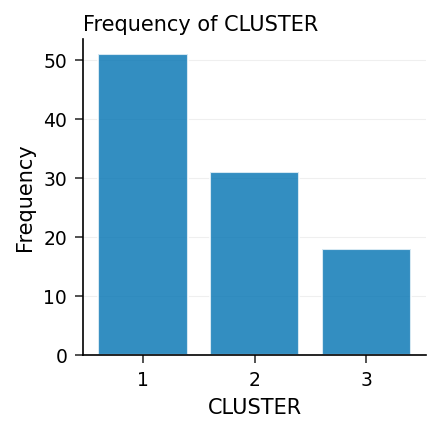

In [6]:
PROZEDUR FASTCLUS DATEN=subs_std maxclusters=3 MAXITER=0 seed=seg_seeds
        out=rescored;
    VAR tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    id cust_id;
    BEZEICHNUNG tenure_months='Vertragsdauer (Monate)' data_gb='Datenvolumen (GB)'
          voice_min='Sprachminuten' intl_min='Auslandsminuten'
          support_calls='Support-Anrufe' monthly_charge='Monatliche Rechnung ($)'
          cust_id='Kundennummer' CLUSTER='Cluster-Nr' distance='Abstand';
    TITEL 'Bewertung einer neuen Momentaufnahme anhand der exportierten Zentren';
AUSFÜHREN;

PROZEDUR HÄUFIGKEITEN DATEN=rescored;
    TABLES CLUSTER / nocum;
    BEZEICHNUNG CLUSTER='Cluster-Nr';
    TITEL 'Neu bewertete Abonnenten über das exportierte Modell';
AUSFÜHREN;

## Die Ergebnisse interpretieren

FASTCLUS hat die drei im Datensatz eingebetteten Verhaltenssegmente wiedergefunden, und die Profiltabellen übersetzen sie in ein Kundenbindungs-Playbook. Lesen Sie die Segmentnummern aus der obigen *Segmentprofile*-Tabelle ab - die Clusterbezeichnungen sind willkürlich, daher identifizieren Sie jede Persona anhand ihrer Nutzungssignatur:

- **Sparsame/preisbewusste Nutzer** - wenig Daten, moderate Rechnungen, längere Vertragsdauer, sehr wenige Support-Anrufe, meist im Tarif *Basis*. Diese Kunden sind stabil und preisbewusst; der richtige Ansatz ist, *Marge zu schützen*, nicht zu rabattieren. Eine passend zugeschnittene Tarifempfehlung verhindert Rechnungsschreck ohne Geschenke.
- **Datenintensive Streamer** - viele Daten, hohe Sprach- und Auslandsminuten, Premium-Rechnungen, meist *Unbegrenzt*. Sie sind loyal und hochwertig: Der Ansatz ist *Upselling und Geräte-Upgrades*, plus proaktive Nachrichten zur Netzqualität, damit eine Konkurrenzaktion sie nicht abwirbt.
- **Betreuungsintensiv/abwanderungsgefährdet** - kurze Vertragsdauer, erhöhtes Support-Anrufvolumen, mittlere Ausgaben. Die häufigen Betreuungskontakte plus geringe Vertragsdauer sind klassische Abwanderungsvorboten. Dies ist das Segment, das ein *proaktives Kundenbindungsangebot* und eine Nachbetreuung zur Servicewiederherstellung verdient.

Wichtige Verfahrensentscheidungen, die dies zuverlässig machten: **PROC STDIZE** verhinderte, dass großskalige Sprachminuten das Support-Anruf-Signal überdeckten; der Pseudo-F-Durchlauf begründete die Clusteranzahl, statt sie zu raten; die `FREQ`-Gewichtung ließ Mehrleitungs-Familienkonten proportional zu ihrem Umfang zählen; und der `OUTSEED=`/`SEED=`-Roundtrip exportierte die Zentren, sodass das Marketingteam jede monatliche Momentaufnahme mit einem einzigen `MAXITER=0`-FASTCLUS-Aufruf neu segmentieren kann - kein erneutes Clustering erforderlich.